# LeakLock Upload And Analysis Notebook

This notebook lets you upload a single image and run it through the layered LeakLock pipeline.

Current pipeline flow:

- YOLOv8 detection layer
- Routing layer
- Face age risk layer
- OCR extraction layer
- OCR risk evaluation layer
- License plate fixed-risk layer

Notes:

- The notebook uses the trained YOLO weights at `runs_sensitive/yolov82/weights/best.pt` by default.
- Face-age estimation uses the Hugging Face ONNX age model by default.
- OCR risk evaluation currently uses the baseline rule-based classifier.
- Upload one image, then run the analysis cell once.
- Results are automatically saved to `analysis_results/json` and summarized in `analysis_results/summary.csv`.

In [ ]:
# Optional: run this once if the environment still needs the notebook dependencies.
# %pip install -r ../requirements.txt
# If you install or upgrade notebook packages here, restart the kernel afterward.

In [37]:
from pathlib import Path
from datetime import datetime
import csv
import importlib
import json
import sys

import ipywidgets as widgets
from IPython.display import Markdown, clear_output, display
from PIL import Image as PILImage

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Force-refresh the local package so notebook runs use the code currently on disk.
for module_name in [name for name in list(sys.modules) if name == 'leaklock' or name.startswith('leaklock.')]:
    sys.modules.pop(module_name, None)

import leaklock
import leaklock.config
import leaklock.pipeline
import leaklock.layers.face_age
import leaklock.services.age_estimators

importlib.reload(leaklock.config)
importlib.reload(leaklock.services.age_estimators)
importlib.reload(leaklock.layers.face_age)
importlib.reload(leaklock.pipeline)
importlib.reload(leaklock)

from leaklock import LeakLockPipeline, PipelineConfig

UPLOAD_DIR = REPO_ROOT / 'uploaded_images'
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = REPO_ROOT / 'analysis_results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
JSON_RESULTS_DIR = RESULTS_DIR / 'json'
JSON_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OCR_RESULTS_DIR = RESULTS_DIR / 'ocr_text'
OCR_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV_PATH = RESULTS_DIR / 'summary.csv'

config = PipelineConfig(repo_root=REPO_ROOT)
pipeline = LeakLockPipeline(config=config)

print(f'Repo root: {REPO_ROOT}')
print(f'Upload folder: {UPLOAD_DIR}')
print(f'Results folder: {RESULTS_DIR}')
print(f'OCR text folder: {OCR_RESULTS_DIR}')
print(f'YOLO weights: {config.yolo_weights_path}')
print('Face age model provider: Hugging Face ONNX')
print(f"Face age model repo: {getattr(config, 'hf_age_model_repo_id', 'configured inside pipeline / unavailable in current kernel cache')}")
print(f"Face age estimator class: {pipeline._face_layer._estimator.__class__.__name__}")
print(f"Face age estimator module: {pipeline._face_layer._estimator.__class__.__module__}")
print(f"OCR provider class: {pipeline._ocr_layer._provider.__class__.__name__}")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

c:\Users\User\anaconda3\envs\pydatafix\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--microsoft--trocr-base-printed. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if 

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Repo root: C:\Users\User\Documents\GitHub\LeakLock
Upload folder: C:\Users\User\Documents\GitHub\LeakLock\uploaded_images
Results folder: C:\Users\User\Documents\GitHub\LeakLock\analysis_results
OCR text folder: C:\Users\User\Documents\GitHub\LeakLock\analysis_results\ocr_text
YOLO weights: C:\Users\User\Documents\GitHub\LeakLock\runs_sensitive\yolov82\weights\best.pt
Face age model provider: Hugging Face ONNX
Face age model repo: onnx-community/age-gender-prediction-ONNX
Face age estimator class: HuggingFaceOnnxAgeEstimator
Face age estimator module: leaklock.services.age_estimators
OCR provider class: FallbackOcrProvider


In [38]:
def iter_uploaded_files(file_upload_value):
    if isinstance(file_upload_value, dict):
        for file_name, payload in file_upload_value.items():
            content = payload['content'] if isinstance(payload, dict) else payload.content
            yield file_name, content
        return

    for item in file_upload_value:
        if isinstance(item, dict):
            file_name = item.get('name', 'uploaded_image')
            content = item.get('content', b'')
        else:
            file_name = getattr(item, 'name', 'uploaded_image')
            content = getattr(item, 'content', b'')
        yield file_name, content


def save_uploaded_file(file_name, content):
    file_path = UPLOAD_DIR / file_name
    file_path.write_bytes(content)
    return file_path


def make_result_basename(image_path):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    return f"{image_path.stem}_{timestamp}"


def append_summary_row(result, image_path, json_path):
    file_exists = SUMMARY_CSV_PATH.exists()
    with SUMMARY_CSV_PATH.open('a', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(
            handle,
            fieldnames=['image_name', 'image_path', 'overall_risk_percent', 'detections_count', 'json_result_path']
        )
        if not file_exists:
            writer.writeheader()
        writer.writerow({
            'image_name': image_path.name,
            'image_path': str(image_path),
            'overall_risk_percent': result.overall_risk_percent,
            'detections_count': len(result.analyses),
            'json_result_path': str(json_path),
        })


def save_ocr_text_file(result, image_path):
    ocr_text_blocks = []
    for analysis in result.analyses:
        evidence = analysis.risk.evidence if hasattr(analysis.risk, 'evidence') else {}
        ocr_info = evidence.get('ocr', {}) if isinstance(evidence, dict) else {}
        text = (ocr_info.get('text') or '').strip() if isinstance(ocr_info, dict) else ''
        if text:
            ocr_text_blocks.append(f"[{analysis.detection.class_name}]\n{text}")

    txt_path = OCR_RESULTS_DIR / f"{make_result_basename(image_path)}.txt"
    txt_path.write_text("\n\n".join(ocr_text_blocks), encoding='utf-8')
    return txt_path


def save_result_files(result, image_path):
    base_name = make_result_basename(image_path)
    json_path = JSON_RESULTS_DIR / f'{base_name}.json'
    json_path.write_text(json.dumps(result.to_dict(), indent=2), encoding='utf-8')
    append_summary_row(result, image_path, json_path)
    ocr_text_path = save_ocr_text_file(result, image_path)
    return json_path, ocr_text_path


def analyze_and_display(image_path):
    display(Markdown(f'## {image_path.name}'))
    display(PILImage.open(image_path))
    result = pipeline.analyze_image(image_path)
    json_path, ocr_text_path = save_result_files(result, image_path)
    print(json.dumps(result.to_dict(), indent=2))
    print(f'JSON result saved to: {json_path}')
    print(f'OCR text saved to: {ocr_text_path}')
    print(f'CSV summary saved to: {SUMMARY_CSV_PATH}')
    return result

## Analyze a file


In [39]:
import hashlib
import ipywidgets as widgets
from IPython.display import display, Markdown

# Close old widget if it exists
if "uploader" in globals():
    try:
        uploader.close()
    except Exception:
        pass

uploader = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
    button_style="primary"
)

display(Markdown("## Upload one image below"))
display(uploader)


## Upload one image below

FileUpload(value=(), accept='image/*', button_style='primary', description='Upload Image')

In [48]:
_last_processed_hash = None

def get_first_uploaded_file(value):
    if isinstance(value, dict) and value:
        name, info = next(iter(value.items()))
        content = info["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return info.get("name", name), content

    if isinstance(value, (tuple, list)) and len(value) > 0:
        info = value[0]
        name = info.get("name", "uploaded_image")
        content = info["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return name, content

    return None, None


def reset_uploader():
    try:
        uploader.value = ()
    except Exception:
        pass
    if hasattr(uploader, "_counter"):
        uploader._counter = 0


## Upload one image below

FileUpload(value=({'name': '4a8c6a2bbfaad2eae7093f43ad216ed5_jpg.rf.83c89213c3d8f73f550f2462ea9b7107.jpg', 'ty…

## 4a8c6a2bbfaad2eae7093f43ad216ed5_jpg.rf.83c89213c3d8f73f550f2462ea9b7107.jpg

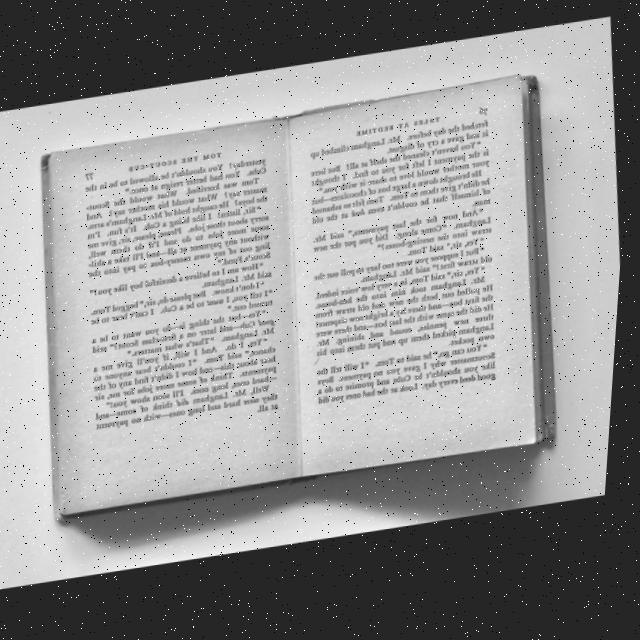

{
  "image_path": "C:\\Users\\User\\Documents\\GitHub\\LeakLock\\uploaded_images\\4a8c6a2bbfaad2eae7093f43ad216ed5_jpg.rf.83c89213c3d8f73f550f2462ea9b7107.jpg",
  "overall_risk_percent": 0,
  "analyses": [
    {
      "detection": {
        "class_id": 1,
        "class_name": "document",
        "confidence": 0.8603008985519409,
        "box": {
          "x1": 40.16310119628906,
          "y1": 65.24734497070312,
          "x2": 540.08984375,
          "y2": 511.6423645019531
        }
      },
      "route": "ocr_extraction_layer",
      "risk": {
        "layer_name": "ocr_risk_evaluation_layer",
        "routed_from_class": "document",
        "risk_percent": 0,
        "reason": "Document text was extracted and reviewed for sensitive personal data",
        "evidence": {
          "ocr": {
            "text": "CASHIER\nCASH\nTAX",
            "provider": "trocr",
            "details": "OCR extracted from cropped detection using model=microsoft/trocr-base-printed"
          },
  

In [49]:
from IPython.display import clear_output, display, Markdown

file_name, content = get_first_uploaded_file(uploader.value)

if content is None:
    print("Upload one image first.")
else:
    file_hash = hashlib.sha1(content).hexdigest()

    if file_hash == _last_processed_hash:
        print("This exact file was already analyzed.")
    else:
        _last_processed_hash = file_hash
        clear_output(wait=True)
        display(Markdown("## Upload one image below"))
        display(uploader)

        try:
            image_path = save_uploaded_file(file_name, content)
            analyze_and_display(image_path)
        except Exception as exc:
            display(Markdown(f"## {file_name}"))
            print(f"Failed to analyze image: {exc}")

        reset_uploader()
